# Optiver 2-Level LOB + Transfer Learning Report

This is the **single Optiver notebook** for the application study. It is organized as a report notebook: the expensive steps run on the cluster through scripts, while this notebook loads the generated artifacts, explains the methodology, and presents the final figures needed for the project report.

Workflow dependency chain:
`optiver zip -> scripts/prepare_optiver.py -> data/optiver_processed/*.npz -> scripts/train_optiver.py -> scripts/analyze_optiver.py -> results/optiver/* -> this notebook`.

## 1. Cluster workflow

```bash
cd /ocean/projects/mth250011p/xxiao7/DeepLOB
sbatch submit_optiver.sh
```

The batch workflow is:
1. `scripts/prepare_optiver.py` — extract 2-level book data, construct labels, and apply **causal time_id-based normalization** using only past buckets.
2. `scripts/train_optiver.py` — run three regimes for the report horizons `k = 1, 5, 10`: universal cross-stock pretraining, zero-shot / fine-tuned transfer on held-out stocks, and same-stock temporal out-of-sample training.
3. `scripts/analyze_optiver.py` — generate the paper-style transfer-learning figures (Figure 6/7/8/9 analogues) and summary JSON.

Key files involved:
- `submit_optiver.sh` — end-to-end cluster wrapper
- `scripts/prepare_optiver.py` — preprocessing + label construction + causal normalization
- `scripts/train_optiver.py` — DeepLOBLite training / transfer / specific-stock OOS
- `scripts/analyze_optiver.py` — notebook-ready transfer figures and summary tables

After the SLURM job finishes, **Run All** in this notebook to render the complete report.

## 2. Setup

In [1]:
import io, json, os, pickle, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

BASE_DIR = Path('/ocean/projects/mth250011p/xxiao7/DeepLOB')
ZIP_PATH = BASE_DIR / 'optiver-realized-volatility-prediction.zip'
DATA_DIR = BASE_DIR / 'data' / 'optiver_processed'
RESULT_DIR = BASE_DIR / 'results' / 'optiver'
HORIZONS = [1, 5, 10]


## 3. Raw Optiver dataset overview

In [2]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    names = zf.namelist()
    tops = sorted(set(n.split('/')[0] for n in names if '/' in n))
    print('Top-level directories:', tops)
    print('Top-level files:', [n for n in names if '/' not in n])
    with zf.open('train.csv') as f:
        df_train = pd.read_csv(f)

print('train.csv shape:', df_train.shape)
display(df_train.head())

Top-level directories: ['book_test.parquet', 'book_train.parquet', 'trade_test.parquet', 'trade_train.parquet']
Top-level files: ['sample_submission.csv', 'test.csv', 'train.csv']
train.csv shape: (428932, 3)


,stock_id,time_id,target
0,0,5,0.004136
1,0,11,0.001445
2,0,16,0.002168
3,0,31,0.002195
4,0,62,0.001747


In [3]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    book_name = next(n for n in zf.namelist() if n.startswith('book_train.parquet/stock_id=0/'))
    trade_name = next(n for n in zf.namelist() if n.startswith('trade_train.parquet/stock_id=0/'))
    df_book = pd.read_parquet(io.BytesIO(zf.read(book_name)))
    df_trade = pd.read_parquet(io.BytesIO(zf.read(trade_name)))

print('Sample book rows')
display(df_book.head())
print('Sample trade rows')
display(df_trade.head())

Sample book rows


,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100


Sample trade rows


,time_id,seconds_in_bucket,price,size,order_count
0,5,21,1.002301,326,12
1,5,46,1.002778,128,4
2,5,50,1.002818,55,1
3,5,57,1.003155,121,5
4,5,68,1.003646,4,1


## 4. Feature arrangement, normalization, and labels

The Optiver dataset only provides the first **two** bid/ask levels, so the input tensor is reduced from 40 features (FI-2010, 10 levels) to 8 features:

```
[ask_price1, ask_size1, bid_price1, bid_size1,
 ask_price2, ask_size2, bid_price2, bid_size2]
```

This ordering is intentional: the first `(1×2, stride=2)` convolution still merges **price + size within the same side and level**, preserving the design logic of the original DeepLOB paper.

To stay closer to the paper's LSE experiment, preprocessing now uses a **causal dynamic normalization**: for each stock, each `time_id` bucket is standardized with statistics estimated from the **previous 5 buckets only**. This is an Optiver approximation to the paper's rolling 5-day z-score idea and avoids leaking future information into the current bucket.

Label construction also differs from FI-2010. Here we build 3-class direction labels from event-horizon mid-price returns with an adaptive threshold

```
return_t(k) = (mid_{t+k} - mid_t) / mid_t
threshold_t = alpha × rolling_std(return_t(k))
```

so the model predicts **Down / Stationary / Up** for horizons `k = 1, 5, 10`.

In [5]:
split_path = DATA_DIR / 'stock_split.json'
if split_path.exists():
    split = json.loads(split_path.read_text())
    print('Train stocks   :', len(split['train']), split['train'][:5], '...', split['train'][-5:])
    print('Transfer stocks:', len(split['transfer']), split['transfer'][:5], '...', split['transfer'][-5:])
else:
    print('Processed Optiver split is not available yet. Submit submit_optiver.sh first.')

Train stocks   : 80 [0, 1, 2, 3, 4] ... [85, 86, 87, 88, 89]
Transfer stocks: 32 [90, 93, 94, 95, 96] ... [122, 123, 124, 125, 126]


## 5. DeepLOBLite architecture

The Optiver model keeps the **Conv + Inception + LSTM** backbone of DeepLOB, but adapts the spatial width to a 2-level order book. The most important structural change is the third convolution block: after two `(1×2)` reductions, the width becomes 2, so the final collapsing convolution uses `(1×2)` instead of the original `(1×10)`.

In [6]:
script = (BASE_DIR / 'scripts' / 'train_optiver.py').read_text()
start = script.index('class DeepLOBLite')
end = script.index('def train_loop(')
print(script[start:end])

class DeepLOBLite(nn.Module):
    """DeepLOB adapted for 2-level LOB (8 input features instead of 40).

    Architecture change vs. original DeepLOB (10 price levels):
      Block 3 uses kernel (1,2) instead of (1,10) to match the 2 remaining
      spatial positions after two (1,2) stride-2 convolutions.

    Input:  (B, 1, T, 8)
    Output: (B, 3) — logits
    """
    def __init__(self, y_len: int = 3):
        super().__init__()
        self.y_len = y_len

        # Block 1: merge bid/ask pairs → (B, 32, T, 4)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1), padding=(2, 0)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1), padding=(1, 0)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        # Block 2: merge levels → (B, 32, T, 2)
        self.conv2 = nn.Sequenti

## 6. Training and transfer-learning protocol

- **Universal feature transfer**: train one shared DeepLOBLite on 80 source stocks, then evaluate it zero-shot on unseen stocks. This is the closest Optiver analogue to the paper's cross-stock transfer experiment.  
- **Fine-tuning**: on each held-out stock, keep the convolution + inception layers frozen and adapt only the **LSTM + classifier head**. This tests whether the universal representation becomes more stock-specific after light adaptation.  
- **Specific-stock out-of-sample**: for the same held-out stocks, also train a model from scratch on the early segment of that stock and test on the later segment. This mirrors the paper's same-stock temporal generalization idea.  
- **Training stabilizers**: because Optiver labels are much more imbalanced than FI-2010, training uses **class-balanced cross-entropy**, **class-balanced sampling**, **smaller mini-batches**, and **macro-F1 early stopping** instead of relying on raw accuracy alone.  
- **Frozen during transfer**: convolution and inception blocks.  
- **Report horizons**: `k = 1, 5, 10`.  
- **Paper-style analysis**: session-level accuracy, normalized profit, cumulative profit, and LIME-style local explanation before/after transfer.

## 7. Artifact status

In [7]:
artifacts = []
for k in HORIZONS:
    artifacts.extend([
        f'base_loss_k{k}.png',
        f'base_metrics_k{k}.pkl',
        f'cm_base_k{k}.png',
        f'transfer_metrics_k{k}.pkl',
        f'transfer_comparison_k{k}.png',
        f'specific_metrics_k{k}.pkl',
        f'transfer_regimes_k{k}.png',
    ])
artifacts.extend([
    'figure6_transfer_accuracy.png',
    'figure7_transfer_profit_tstats.png',
    'figure8_transfer_cum_profit.png',
    'figure9_transfer_lime.png',
    'transfer_analysis_summary.json',
])
status = pd.DataFrame({
    'artifact': artifacts,
    'exists': [(RESULT_DIR / name).exists() for name in artifacts],
})
display(status)

,artifact,exists
0,base_loss_k1.png,True
1,base_metrics_k1.pkl,True
2,cm_base_k1.png,True
3,transfer_metrics_k1.pkl,True
4,transfer_comparison_k1.png,True
5,base_loss_k5.png,True
6,base_metrics_k5.pkl,True
7,cm_base_k5.png,True
8,transfer_metrics_k5.pkl,True
9,transfer_comparison_k5.png,True


## 8. Per-horizon training artifacts

k=1


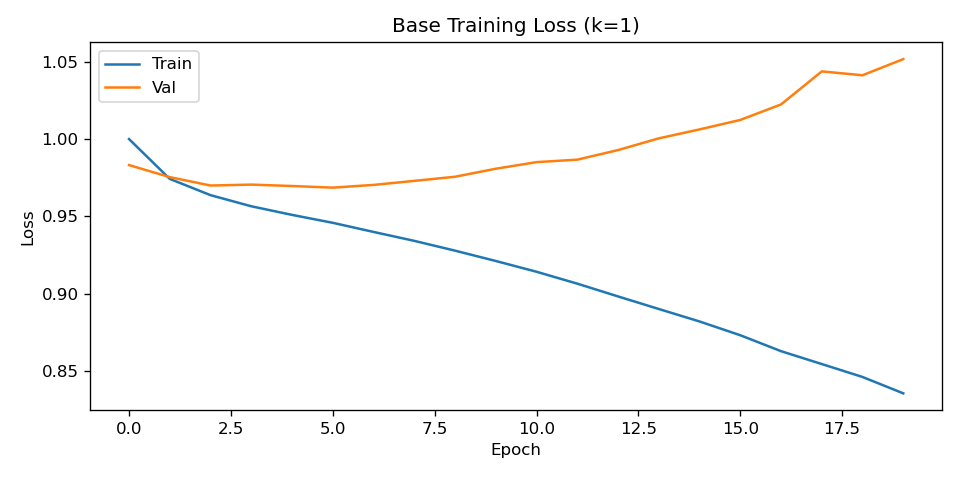

k=5


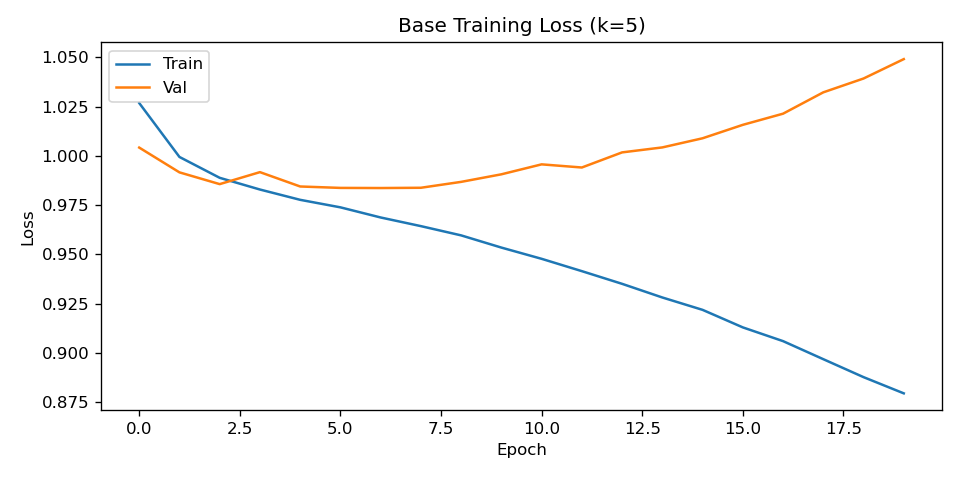

k=10


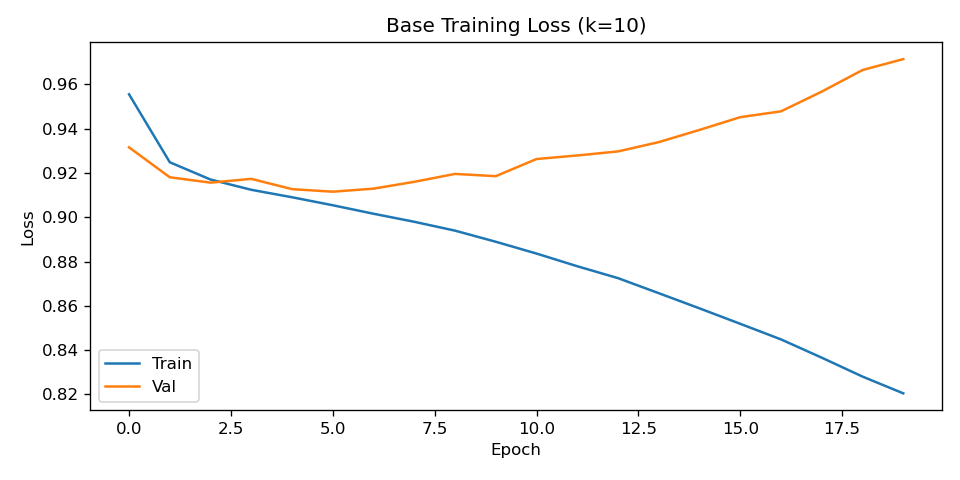

In [8]:
for k in HORIZONS:
    path = RESULT_DIR / f'base_loss_k{k}.png'
    print(f'k={k}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('  base loss curve not available yet.')

k=1


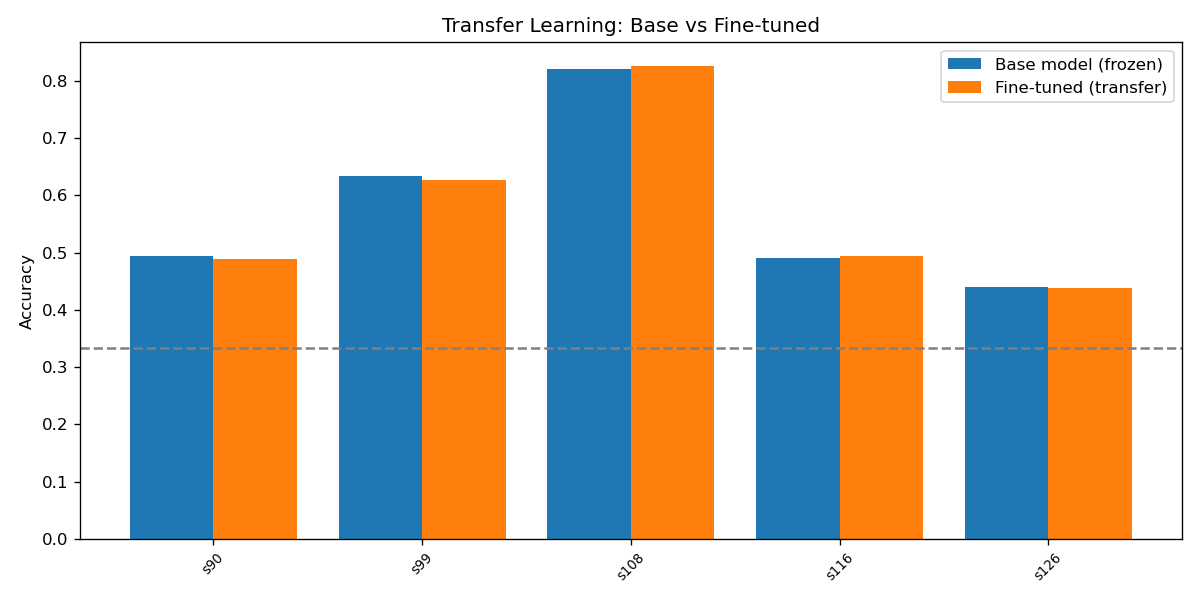

k=5


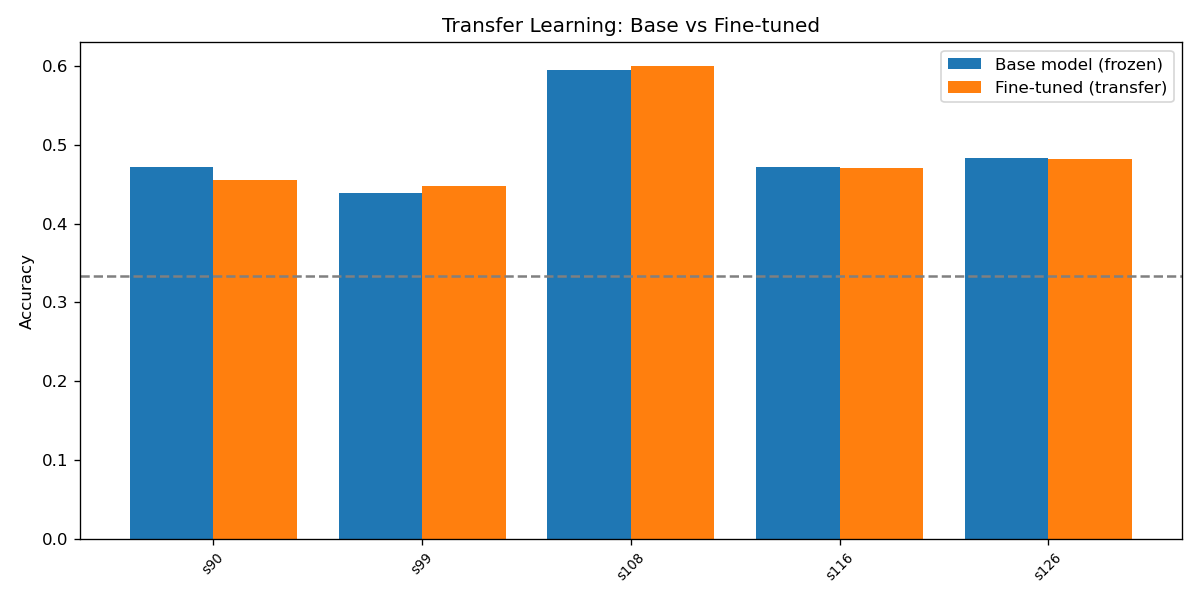

k=10


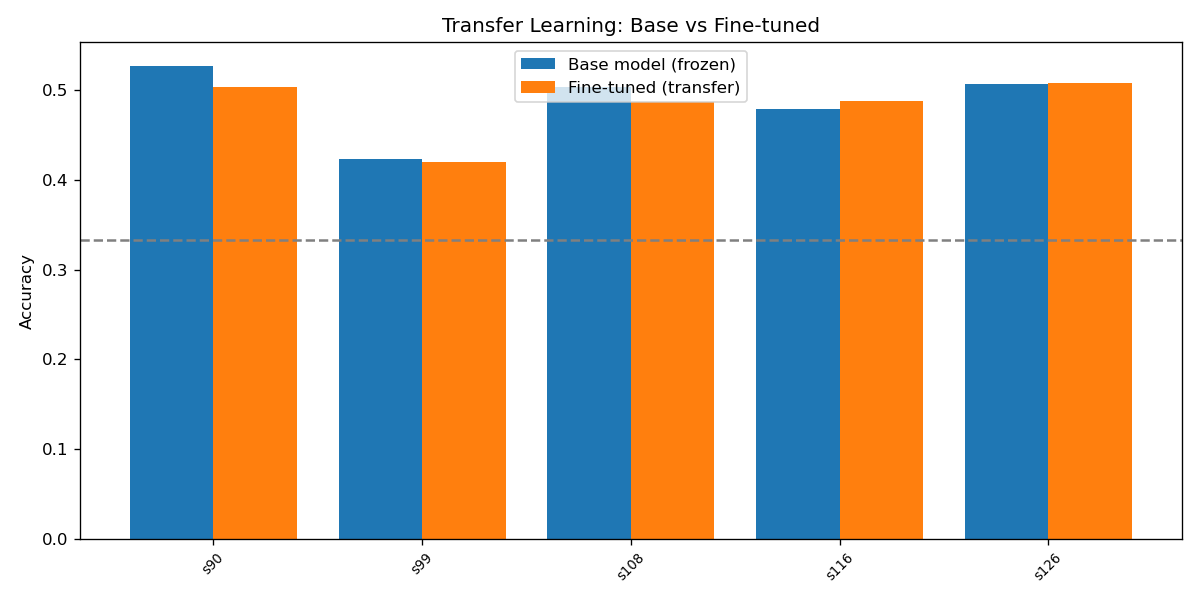

In [9]:
for k in HORIZONS:
    print(f'k={k}')
    for name in [f'transfer_comparison_k{k}.png', f'transfer_regimes_k{k}.png']:
        path = RESULT_DIR / name
        print(' ', name)
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print('   not available yet.')

## 9. Summary tables across held-out transfer stocks

In [10]:
summary_path = RESULT_DIR / 'transfer_analysis_summary.json'
specific_frames = []
for k in HORIZONS:
    path = RESULT_DIR / f'specific_metrics_k{k}.pkl'
    if path.exists():
        with open(path, 'rb') as f:
            payload = pickle.load(f)
        for row in payload.get('per_stock', []):
            specific_frames.append({
                'stock_id': row['stock_id'],
                'horizon_k': k,
                'specific_accuracy': row['metrics']['accuracy'],
                'specific_kappa': row['metrics']['kappa'],
            })

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    df_summary = pd.DataFrame(summary['per_stock_horizon'])
    if specific_frames:
        df_specific = pd.DataFrame(specific_frames)
        df_summary = df_summary.merge(df_specific, on=['stock_id', 'horizon_k'], how='left')
    display(df_summary.sort_values(['horizon_k', 'stock_id']).reset_index(drop=True))
else:
    print('transfer_analysis_summary.json not available yet.')

,stock_id,horizon_k,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta
0,90,1,0.493889,0.488889,-0.005000,0.009571,0.016351,0.006781
1,99,1,0.633889,0.626667,-0.007222,0.009956,0.003808,-0.006148
2,108,1,0.821667,0.826111,0.004444,-0.000859,0.001967,0.002826
3,116,1,0.490556,0.493333,0.002778,-0.003245,0.000261,0.003507
4,126,1,0.439444,0.438333,-0.001111,0.003771,0.003871,0.000100
5,90,5,0.472222,0.455000,-0.017222,0.064311,0.031976,-0.032335
6,99,5,0.438333,0.447778,0.009444,0.070627,0.072151,0.001523
7,108,5,0.595000,0.600000,0.005000,0.009178,-0.002882,-0.012060
8,116,5,0.471667,0.470556,-0.001111,0.112613,0.101419,-0.011195
9,126,5,0.482778,0.481667,-0.001111,0.087891,0.071344,-0.016547


In [11]:
if summary_path.exists():
    df_summary = pd.DataFrame(json.loads(summary_path.read_text())['per_stock_horizon'])
    pivot = df_summary.pivot_table(index='stock_id', columns='horizon_k', values='accuracy_delta')
    print('Accuracy gain from transfer learning (after - before):')
    display(pivot)
    if specific_frames:
        df_specific = pd.DataFrame(specific_frames)
        pivot_specific = df_specific.pivot_table(index='stock_id', columns='horizon_k', values='specific_accuracy')
        print('Specific-stock temporal OOS accuracy:')
        display(pivot_specific)

Accuracy gain from transfer learning (after - before):


horizon_k,1,5,10
stock_id,,,
90,-0.005000,-0.017222,-0.023889
99,-0.007222,0.009444,-0.003889
108,0.004444,0.005000,-0.017222
116,0.002778,-0.001111,0.008333
126,-0.001111,-0.001111,0.001111


## 10. Paper-style Figure 6 / 7 / 8 / 9 analogues

figure6_transfer_accuracy.png


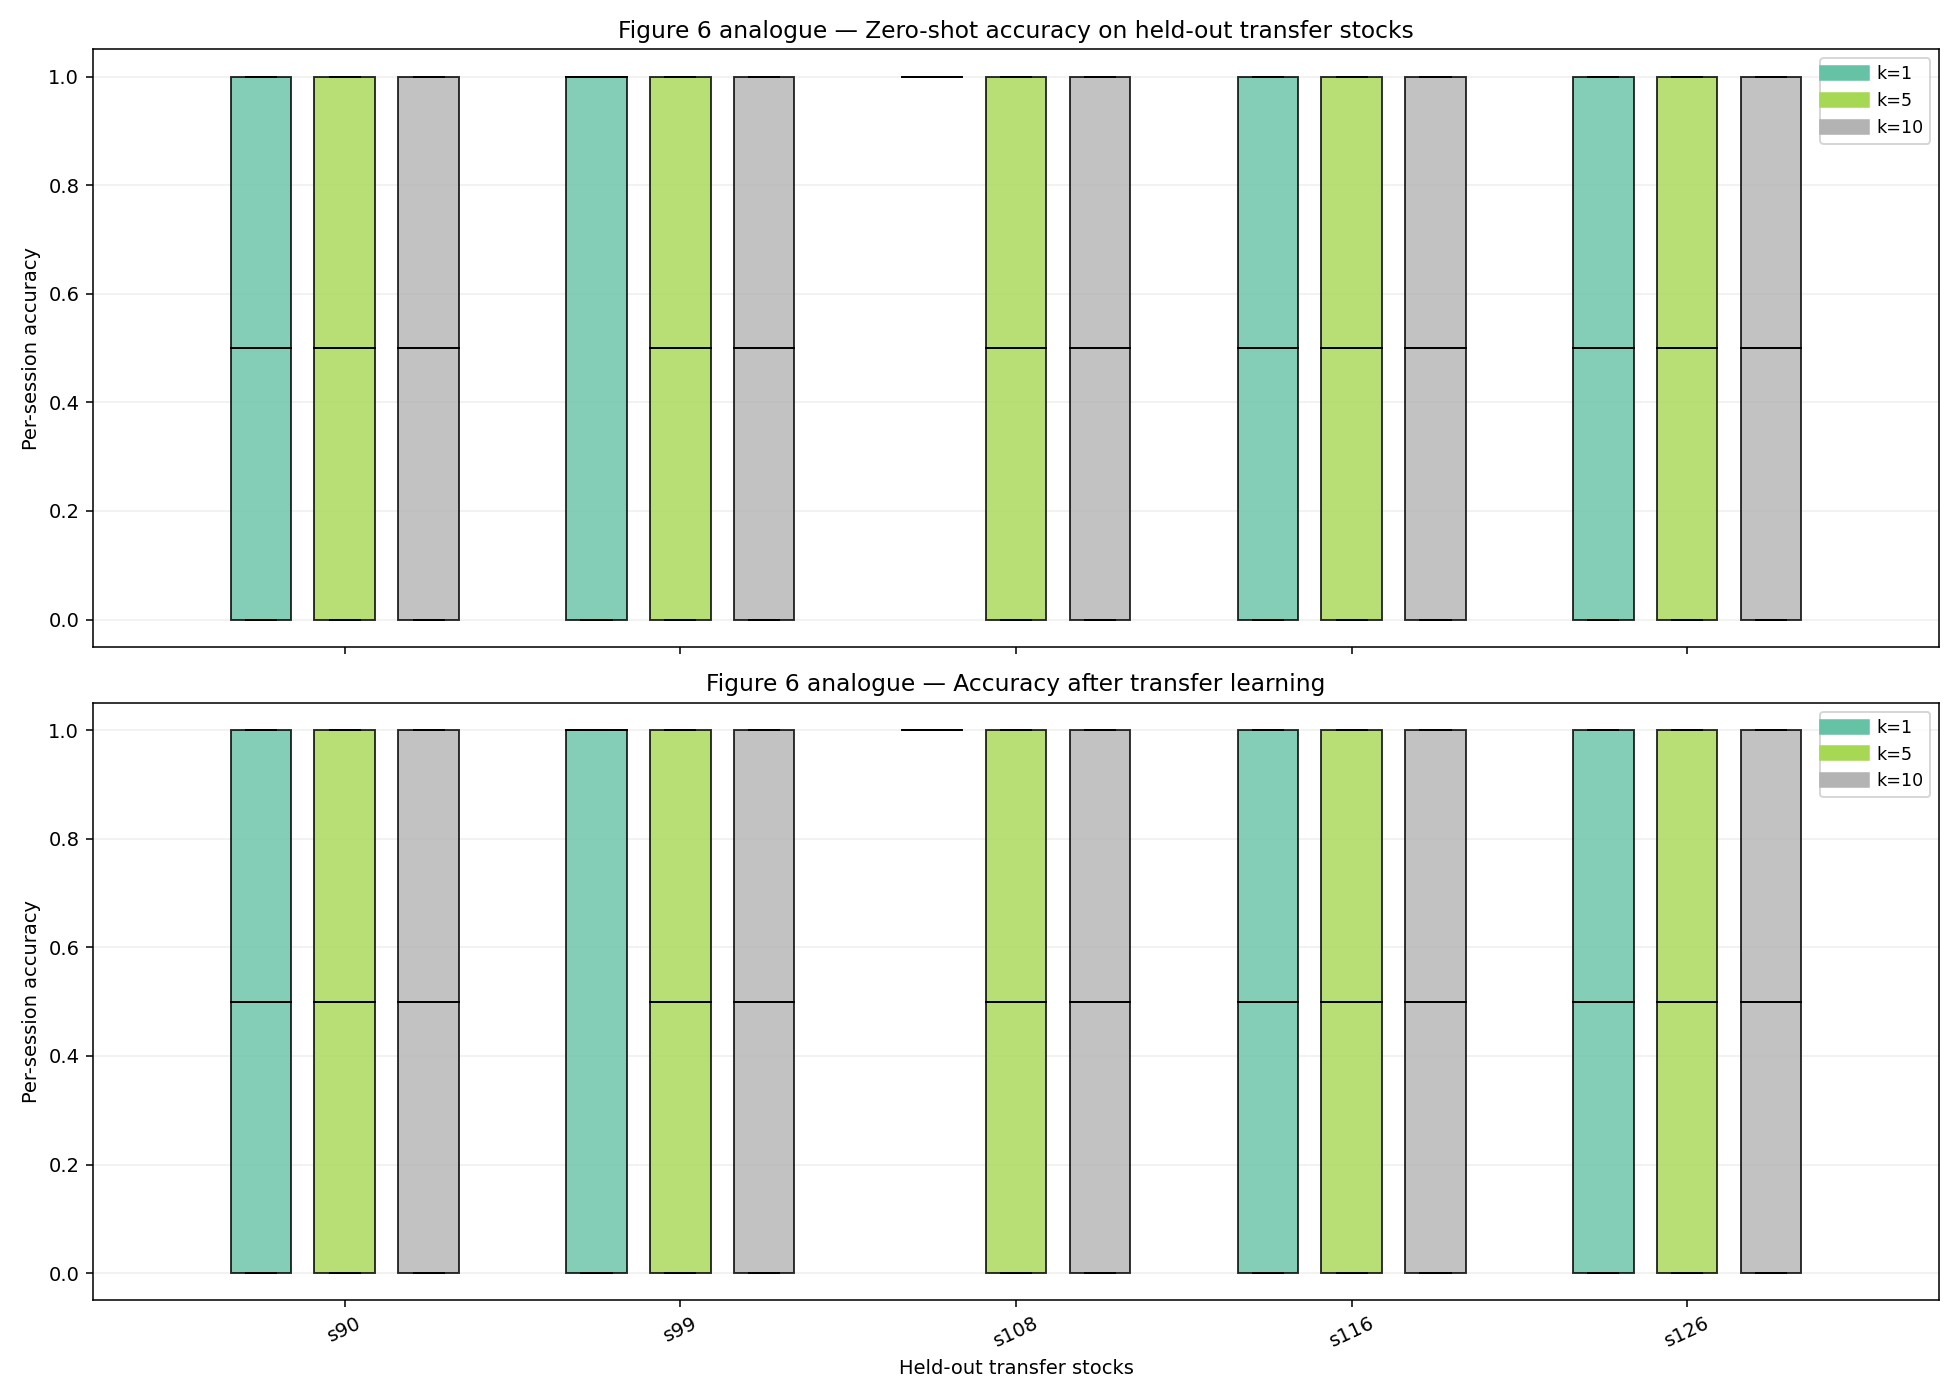

figure7_transfer_profit_tstats.png


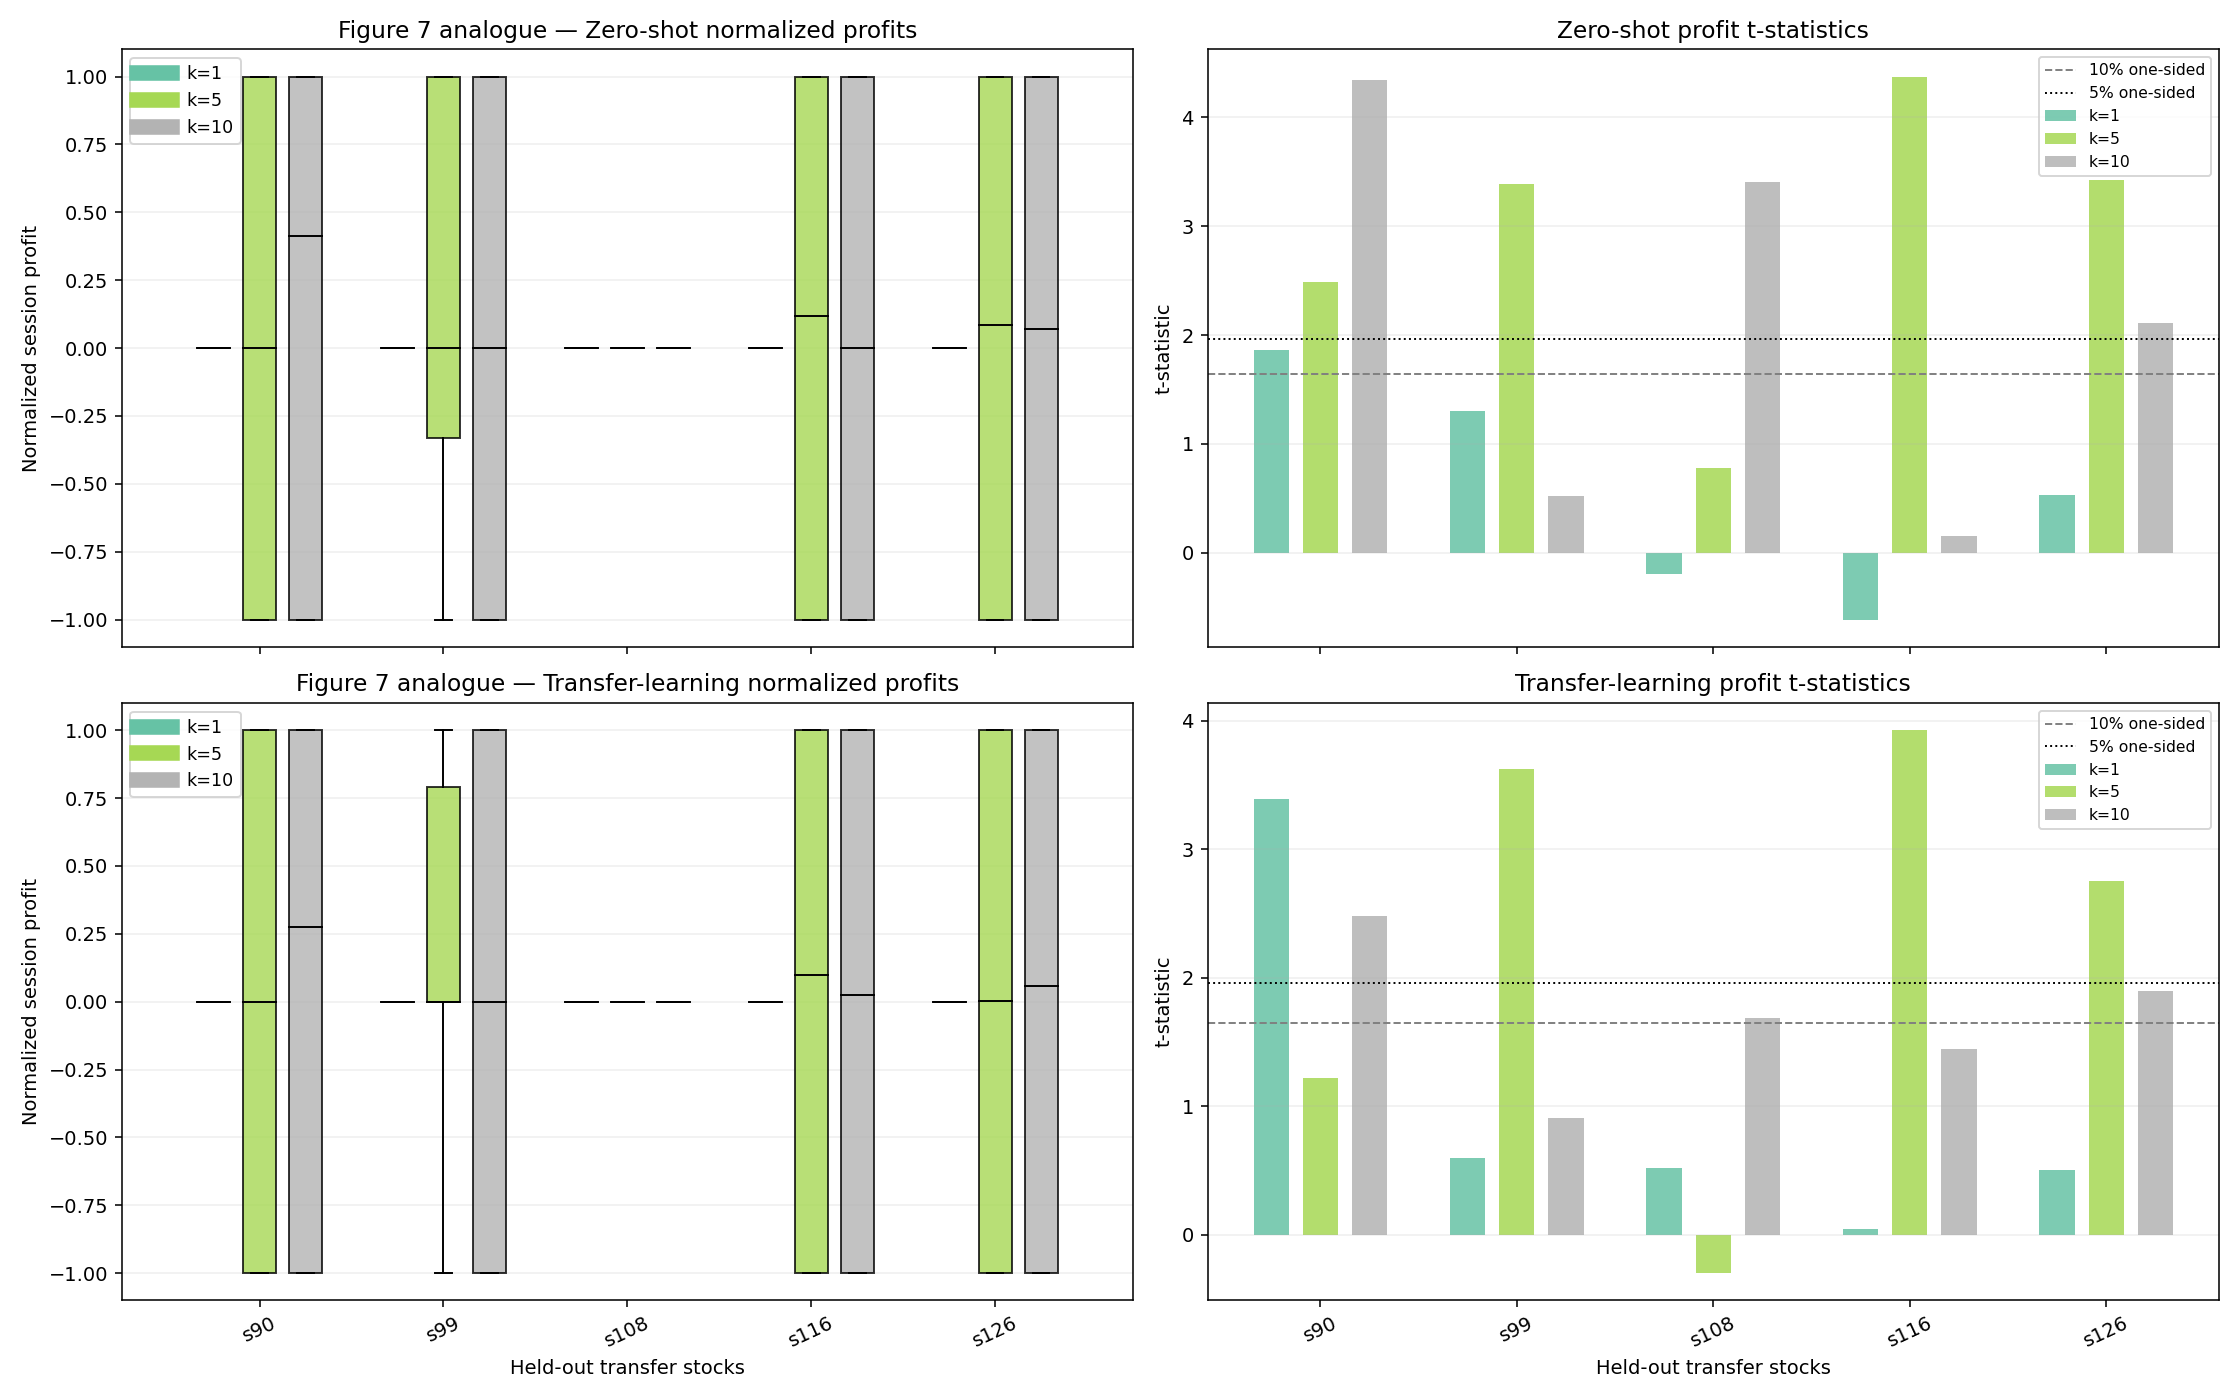

figure8_transfer_cum_profit.png


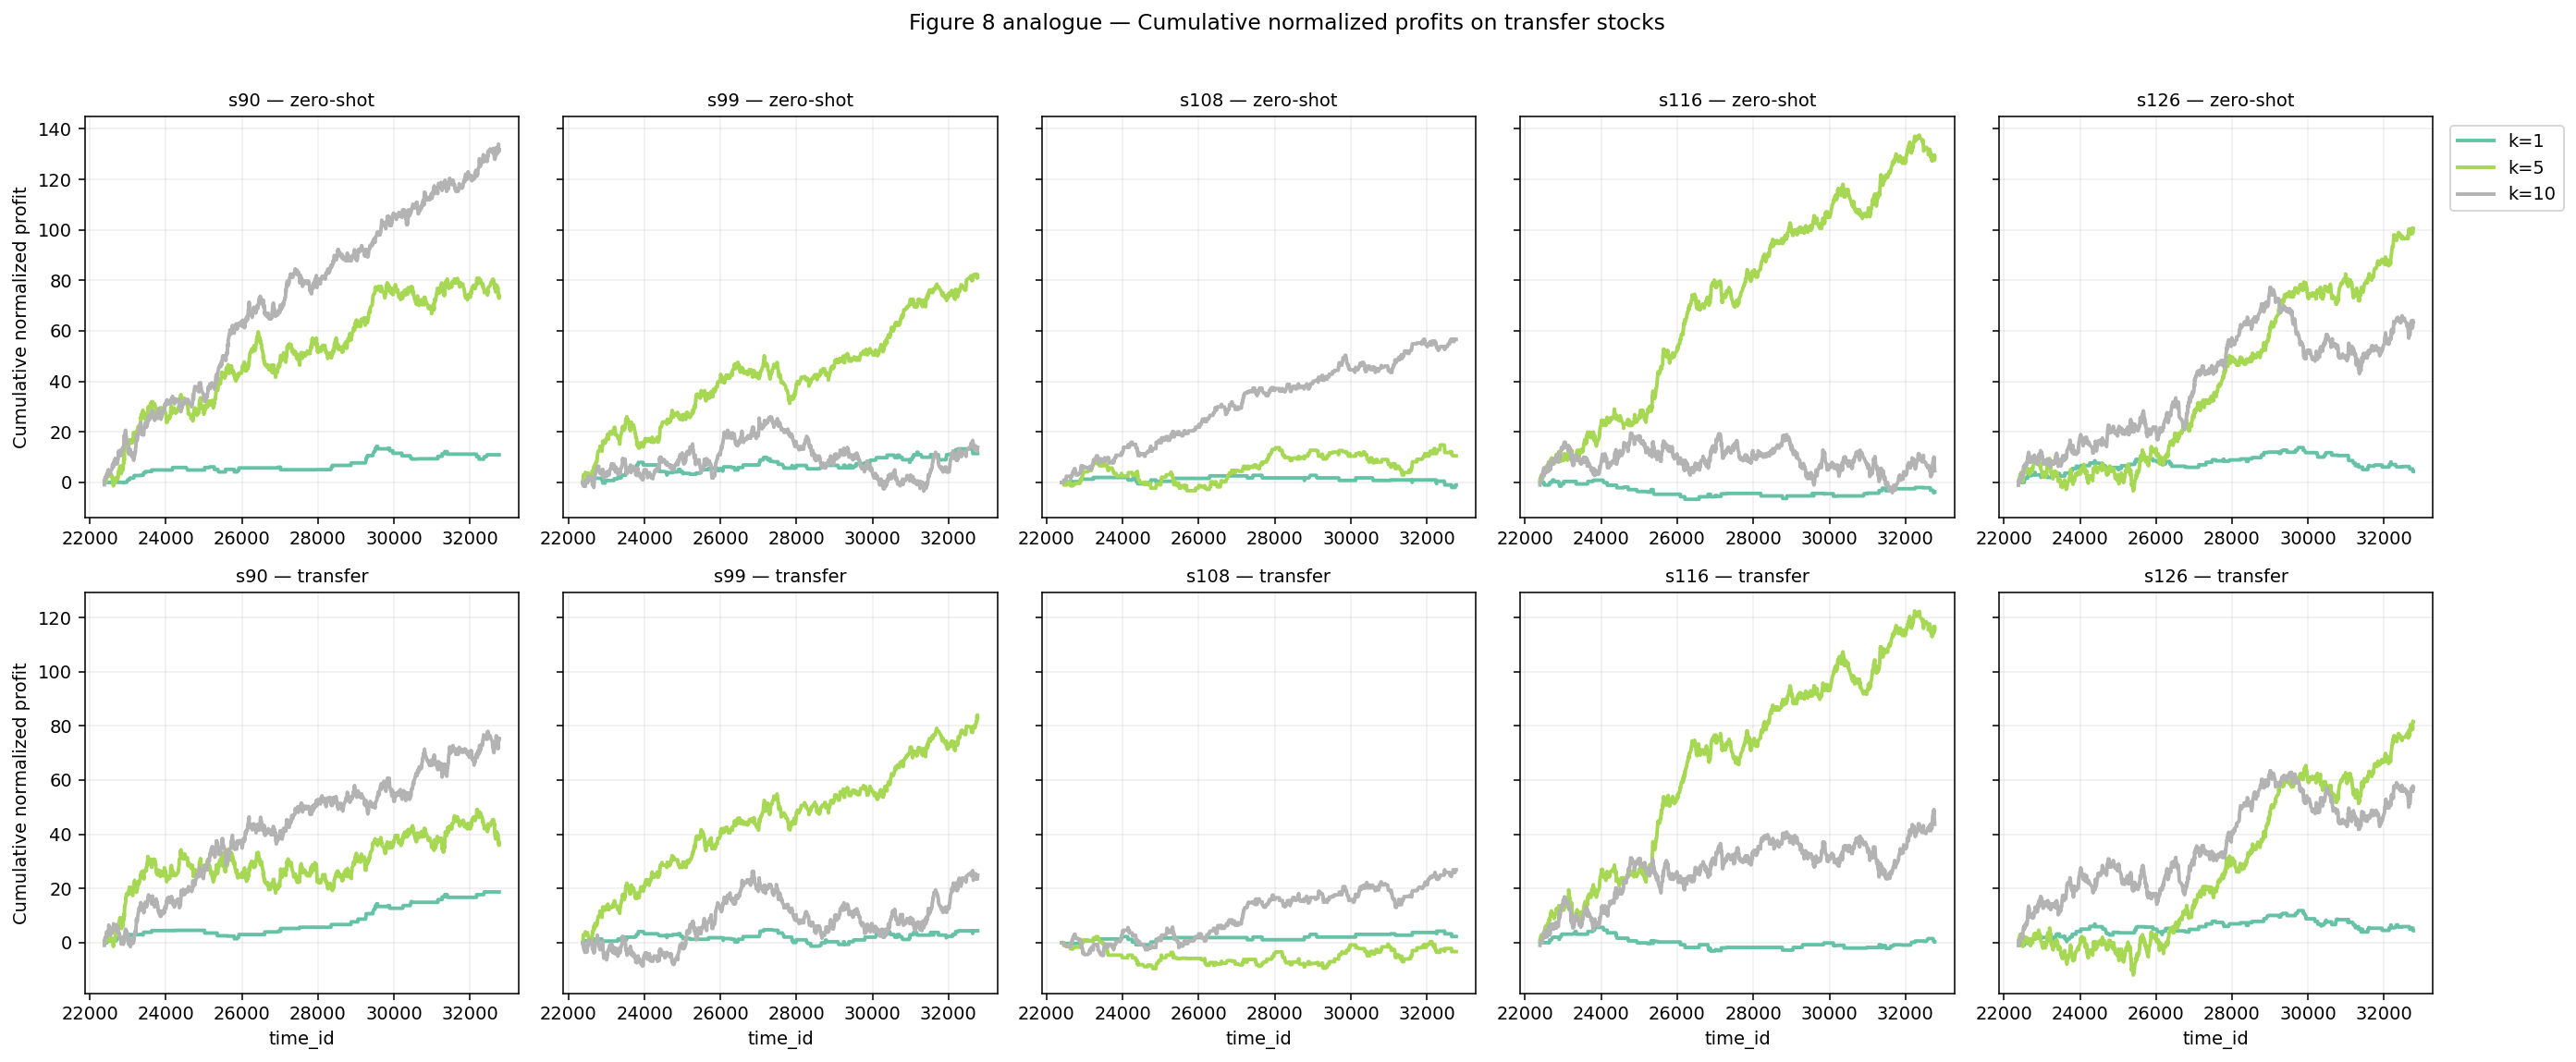

figure9_transfer_lime.png


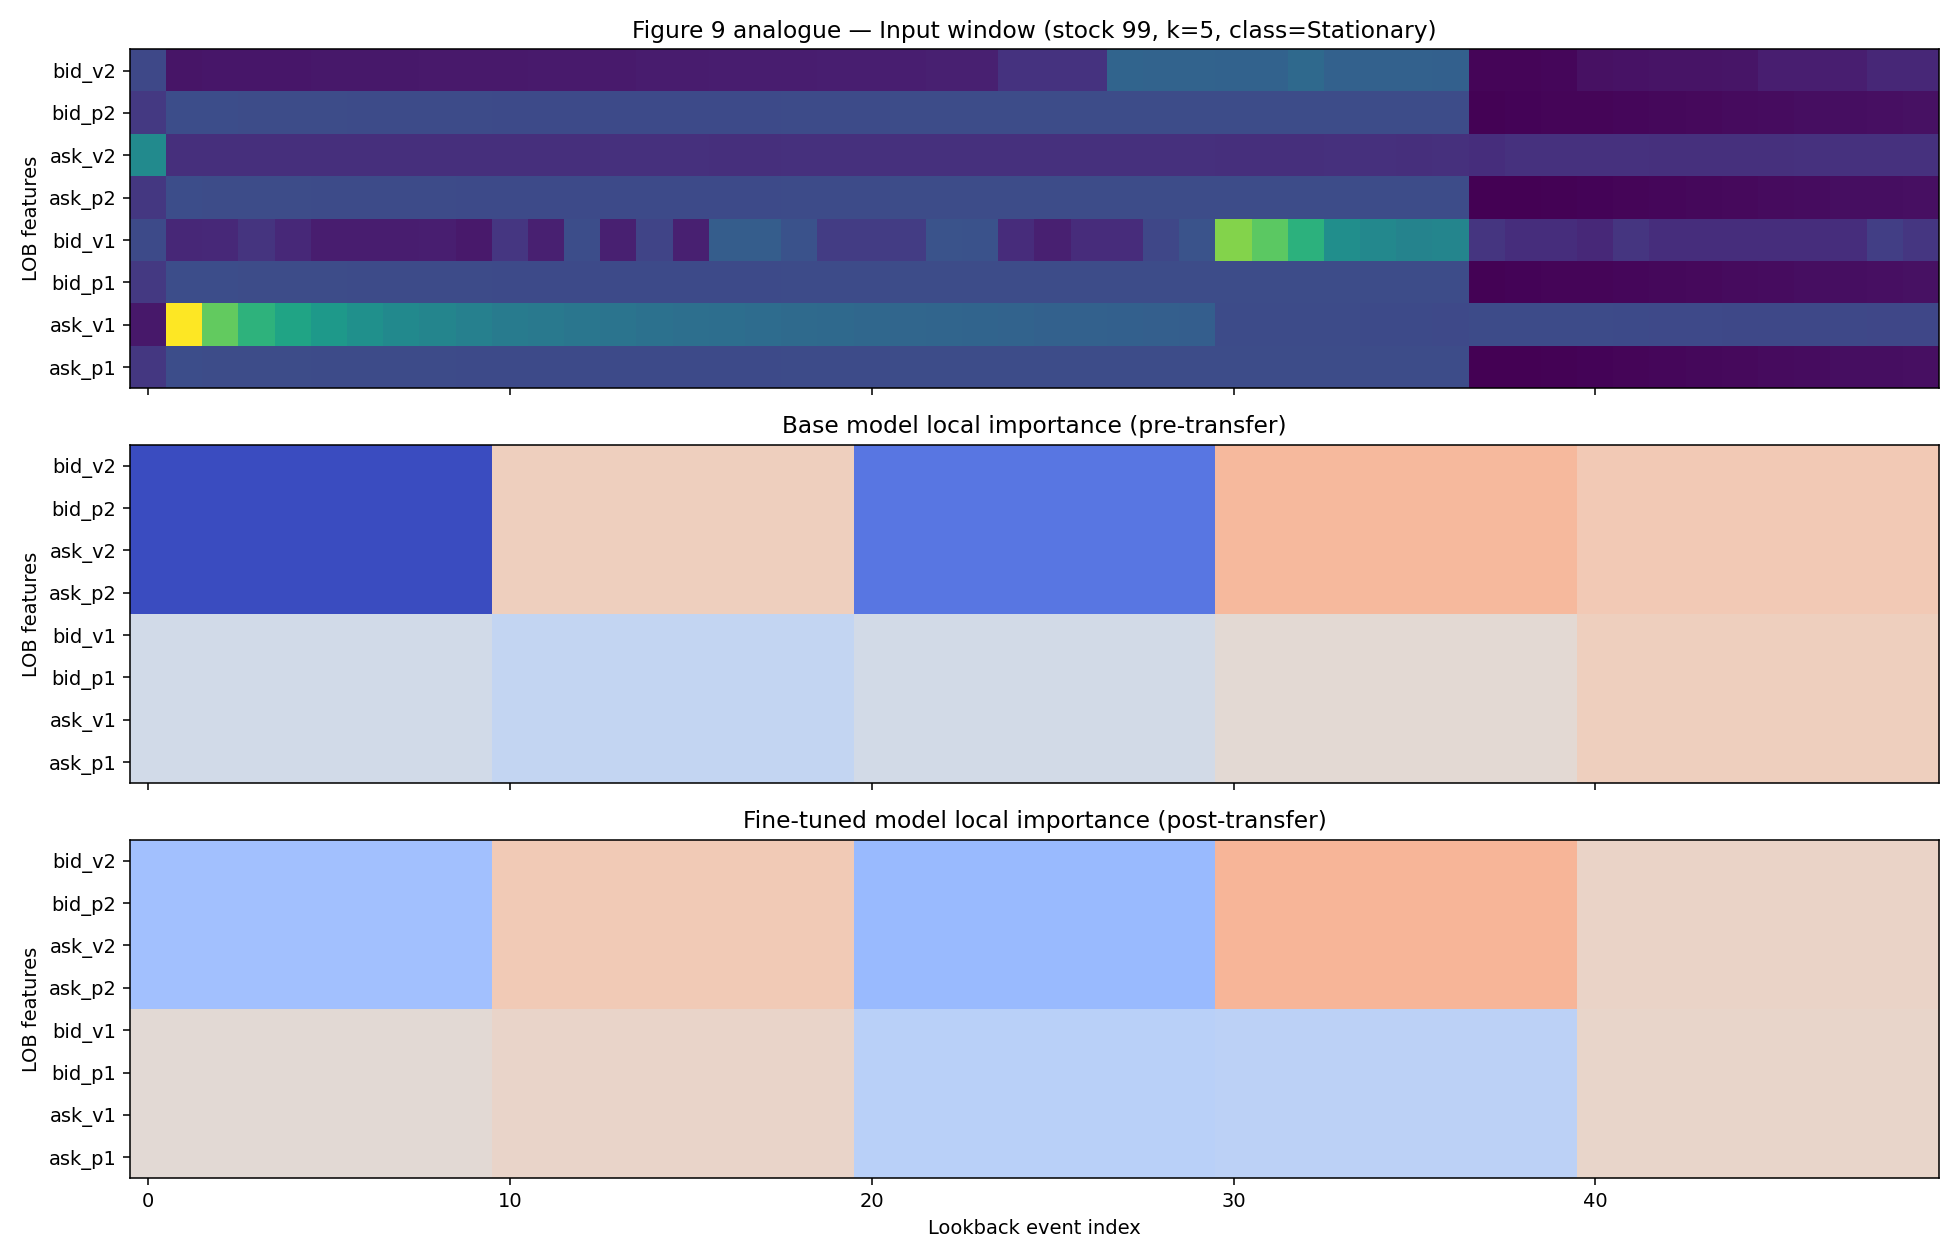

In [12]:
figure_names = [
    'figure6_transfer_accuracy.png',
    'figure7_transfer_profit_tstats.png',
    'figure8_transfer_cum_profit.png',
    'figure9_transfer_lime.png',
]
for name in figure_names:
    path = RESULT_DIR / name
    print(name)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('  not available yet.')

## 11. Interpretation

The four report figures should be read as follows:

- **Figure 6** compares per-session classification accuracy before and after transfer learning. If the lower panel shifts upward relative to the upper panel, transfer learning is helping the held-out stocks.
- **Figure 7** converts the classifier outputs into a simple direction-based trading signal and summarizes whether the profit distribution improves after transfer. Positive t-statistics above the dashed confidence lines indicate more reliable profits.
- **Figure 8** shows whether those gains accumulate persistently through time instead of coming from a few isolated sessions.
- **Figure 9** is a LIME-style local surrogate explanation. It highlights which time-feature regions of the 2-level LOB the model relies on before transfer and how those importance regions shift after fine-tuning on the target stock.

In this notebook the transfer story is therefore split into three complementary questions:

- **Specific-stock out-of-sample**: does a model trained on the early part of one stock still work on the later part of that same stock?
- **Universal zero-shot transfer**: do features learned from many source stocks work immediately on a stock never seen in training?
- **Fine-tuned transfer**: after freezing the universal convolutional representation, does adapting the temporal head improve the target stock further?

Because Optiver is not the original FI-2010 benchmark, these figures are **application-study analogues** rather than exact copies of the paper's experiment. The goal is to check whether the DeepLOB representation transfers across stocks and whether the transferred model becomes more stock-specific after fine-tuning.

In [13]:
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    df_summary = pd.DataFrame(summary['per_stock_horizon'])
    best = df_summary.sort_values('accuracy_delta', ascending=False).iloc[0]
    worst = df_summary.sort_values('accuracy_delta', ascending=True).iloc[0]
    print('Best transfer improvement:')
    display(best.to_frame().T)
    print('Weakest transfer improvement:')
    display(worst.to_frame().T)
    if 'lime_case' in summary:
        print('Figure 9 example case:', summary['lime_case'])
else:
    print('Interpretation summary will be available after the cluster job finishes.')

Best transfer improvement:


,stock_id,horizon_k,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta
6,99.0,5.0,0.438333,0.447778,0.009444,0.070627,0.072151,0.001523


Weakest transfer improvement:


,stock_id,horizon_k,accuracy_before,accuracy_after,accuracy_delta,profit_before_mean,profit_after_mean,profit_delta
10,90.0,10.0,0.526667,0.502778,-0.023889,0.115279,0.065903,-0.049376


Figure 9 example case: {'stock_id': 99, 'horizon_k': 5, 'sample_index': 1264, 'true_class': 'Stationary'}
